الجزء الاول 
EDA

In [368]:
import seaborn as sns
import pandas as pd

titanic = sns.load_dataset('titanic')

# تعمّد إضافة صفوف مكررة (زي ما بيصير بخطأ إدخال بيانات حقيقي)
duplicated_rows = titanic.sample(15, random_state=42)
messy_titanic = pd.concat([titanic, duplicated_rows], ignore_index=True)

# تعمّد خلط شكل النصوص ببعض القيم (Inconsistent Casing، زي ما بيصير لما ناس مختلفين يدخلوا بيانات)
messy_titanic.loc[messy_titanic.sample(20, random_state=1).index, 'embark_town'] = \
    messy_titanic.loc[messy_titanic.sample(20, random_state=1).index, 'embark_town'].str.upper()

# جدول ثاني صغير لازم تدمجه مع messy_titanic
class_info = pd.DataFrame({
    'pclass': [1, 2, 3],
    'class_description': ['First Class - Luxury', 'Second Class - Standard', 'Third Class - Economy'],
    'deck_access': ['Full Access', 'Limited Access', 'No Access']
})

In [369]:
print(titanic.shape)
print(messy_titanic.shape)

(891, 15)
(906, 15)


In [370]:
print(titanic.isnull().sum().sort_values(ascending = False))
print()
print(messy_titanic.isnull().sum().sort_values(ascending = False))

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

deck           701
age            180
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64


In [371]:
print(titanic.isnull().mean().sort_values(ascending = False)*100)
print()
print(messy_titanic.isnull().mean().sort_values(ascending = False)*100)

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
survived        0.000000
pclass          0.000000
sex             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
class           0.000000
who             0.000000
adult_male      0.000000
alive           0.000000
alone           0.000000
dtype: float64

deck           77.373068
age            19.867550
embarked        0.220751
embark_town     0.220751
survived        0.000000
pclass          0.000000
sex             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
class           0.000000
who             0.000000
adult_male      0.000000
alive           0.000000
alone           0.000000
dtype: float64


In [372]:
print(titanic.duplicated().sum())
print()
print(messy_titanic.duplicated().sum())

107

120


In [373]:
print(titanic["embark_town"].unique())
print()
print(messy_titanic["embark_town"].unique())

['Southampton' 'Cherbourg' 'Queenstown' nan]

['Southampton' 'Cherbourg' 'Queenstown' 'SOUTHAMPTON' 'CHERBOURG' nan
 'QUEENSTOWN']


In [374]:
#اولا وجدت قيم مفقودة بالاعمدة التالية 
# deck           701 هاد العمود 77 % منه مفقود 
# age            180 هاد العمود 19.8 % منه مفقود 
#العمودين المتبقيين لم يتجازو نسبة المفودفيهم ال 0.3% 
# embarked         2
# embark_town      2

# يوجد 120 صف مكرر بالداتا المحدثه بينما كانت 107 صفوف بالداتا الاصليه

# يوجد خطأ بادخال النصوص في embark_town ('Southampton' 'Cherbourg' 'Queenstown' 'SOUTHAMPTON' 'CHERBOURG' nan
# 'QUEENSTOWN') كتابة اسم الميناء بحروف كبيرة



الجزء الثاني 
التنظيف و الدمج

In [375]:
messy_titanic.drop_duplicates(inplace=True)

In [376]:
messy_titanic.shape
# هيك احنا حذفنا الصفوف المكررة يلي هي 120 صف و صارت الداتا خالية من التكرارات


(786, 15)

In [377]:
messy_titanic["embark_town"]=messy_titanic["embark_town"].str.title()
messy_titanic["embark_town"].unique()

# هون وحدنا تناسق النصوص بحيث اصبحت جميع النصوص في هذا العمود تبدأ بحرف كبير و الباقي حروف صغيرة
# بعد ما حفظنا تناسق الحروف النصوص صارت القيم المتفردة 3 بدل 6 

array(['Southampton', 'Cherbourg', 'Queenstown', nan], dtype=object)

29.869351032448375
28.25
0    24.0
Name: age, dtype: float64


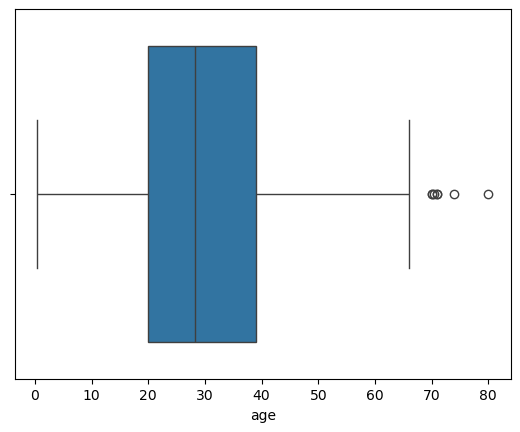

In [378]:
# بالنسبة لمعالجة عمود العمر ف أولا بدي شوف اذا في قيم شاذة و متطرفة لانه ممكن تاثر على المتوسط بالتالي الوسيط بكون افضل بهيك حالة
sns.boxplot(x=messy_titanic["age"])
print(messy_titanic["age"].mean())
print(messy_titanic["age"].median())
print(messy_titanic["age"].mode())

# الظاهر من التحليل ان اغلب الاعمار تقريبا بين 20 و 40 , الوسيط 28 و المتوسط 29.8 ,يوجد بعد القيم الشاذة ايضا 
# مع انحراف موجب(positive skew)
# الان نظرا لوجود بعض القيم الشاذة التي ممكن ان تؤثر على حتى لو بشكل طفيف ف من الافضل استبدال القيم المفقودة بلوسيط
# لانه لا يتاثر بالقيم المتطرفة

In [379]:
messy_titanic["age"]= messy_titanic["age"].fillna(messy_titanic["age"].median())
messy_titanic["age"].isnull().sum()

# هون استبدلنا القيم المفقودة بالوسيط و اصبح عمود العمر خالي من لقيم المفقودة

np.int64(0)

In [380]:
messy_titanic["embarked"].mode()
messy_titanic["embarked"]=messy_titanic["embarked"].fillna(messy_titanic["embarked"].mode()[0])
messy_titanic["embarked"].isnull().sum()

messy_titanic["embark_town"].mode()
messy_titanic["embark_town"]=messy_titanic["embark_town"].fillna(messy_titanic["embark_town"].mode()[0])
messy_titanic["embark_town"].isnull().sum()



#هون استبدلت القيم المفقودو في كلا العمودين embarked & embark_town بالقيمه الاكثر تكرار 

np.int64(0)

In [381]:
# اما بالنسبة لعمود deck فان حذف العمود افضل 
#  العمود يفقتد ما نسبته 77% من البيانات بالتالي عدم وجود القيم الحقيقيه لتلك البيانات و تعويضها بقيم افترضيه ممكن يوثر على عملية التحليل الذي بدوره يوثر على النتجة النهائية
messy_titanic = messy_titanic.drop(columns="deck")
print(messy_titanic.duplicated().sum())

6


In [382]:
print(messy_titanic.isnull().sum())
print()
print(messy_titanic.duplicated().sum())
#ظهرت لدينا 6 تكرارات جديدة بعد حذف عمود deck و هذا يعني انه هذه التسجيلات كات تختلف بعمود الdeck

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

6


In [383]:
messy_titanic.drop_duplicates(inplace=True)
print(messy_titanic.isnull().sum())
print()
print(messy_titanic.duplicated().sum())
print(messy_titanic.shape)

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

0
(780, 14)


In [384]:
#هيك الداتا صارت نظيفة و بامكاننا ننتقل للخطوه القادمة و ندمج الداتا

In [385]:
class_info.shape
class_info.columns

Index(['pclass', 'class_description', 'deck_access'], dtype='object')

In [386]:
messy_titanic=pd.merge(messy_titanic,class_info,on="pclass",how="left")

In [387]:
messy_titanic.shape
# هيك صارت messy_titanic فيها عمودين اضافيين اخدناهم عن طريق class_info بناءا على pclass
# فصارت الداتا عنا فيها عمودين class_description , deck_access

(780, 16)

الجزء الثالث
Visual Report

Question #1
شو توزيع الركاب حسب الفئة وحسب الجنس مع بعض؟

In [388]:
import matplotlib.pyplot as plt
import plotly.express as px

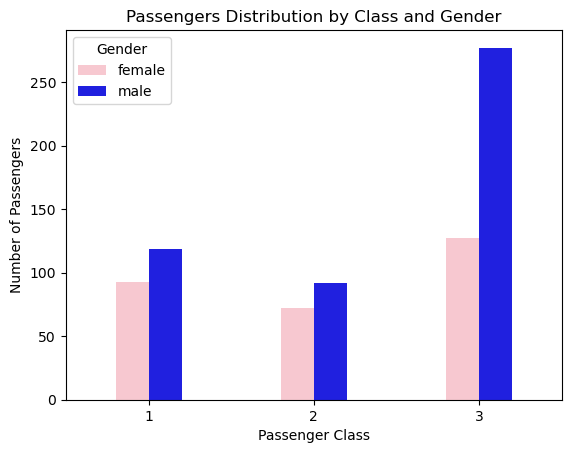

In [389]:
# مقارنة عدد ركاب بين الفئات المختلفة بالتالي رح استخدم barplot
passengers_dist = messy_titanic.groupby(["pclass","sex"]).size().reset_index(name = "number_of_passengers")
passengers_dist
fig_1 = sns.barplot(passengers_dist,y = "number_of_passengers",x="pclass",hue="sex",
                    palette={"female":"pink","male":"blue"},width=0.4)
fig_1.set_title("Passengers Distribution by Class and Gender")
fig_1.set_xlabel("Passenger Class")
fig_1.set_ylabel("Number of Passengers")
plt.legend(title = "Gender")

نلاحظ ان عدد الركاب من الدرجة الثالثه كان اعلى من الدرجتين الاولى و الثانيه , كما ان عدد الركاب الذكور اعلى من الاناث في كل الفئات

Question #2
شو العلاقة بين سعر التذكرة والفئة (class_description الجديد من الدمج)؟

In [390]:
# هون بدي شوف توزيع الاسعار بكل فئة كيف العلاقة بينها و بين الاسعار بالتالي ال boxplot بتعطيني صورة اوضح
fig_2 = px.box(messy_titanic,x="class_description",y="fare",title="Ticket Fare Disribution by Passengers Class",
               labels={"class_description":"Passenger Class","fare":"Ticket fare"})
fig_2.write_html("Ticket Fare Disribution by Passengers Class.html")
fig_2.show()



تظهر الدرجة الأولى تفاوت وتشتت كبير في أسعار التذاكر مقارنة بالدرجتين الثانية والثالثة، اللتين تتميزان بنطاق أسعار ضيق ومستويات أسعار منخفضة بوجه عام. كما يلاحظ وجود قيمة شاذة (متطرفة) بارزة جداً في الدرجة الأولى تجاوزت 500 وحدة نقدية، على عكس الدرجتين الأخريين اللتين تخلوان من تواجد قيم شاذة بهذا الحجم

Question #3
شو نسبة النجاة حسب ميناء الصعود (embark_town)

In [391]:
survival_port = messy_titanic.groupby("embark_town")["survived"].mean().reset_index(name="Survival_Percentage").sort_values(by = "Survival_Percentage",ascending=False)
survival_port["Survival_Percentage"]=survival_port["Survival_Percentage"]*100
survival_port

,embark_town,Survival_Percentage
0,Cherbourg,58.064516
2,Southampton,37.389771
1,Queenstown,34.482759


Text(0, 0.5, 'Embark Town')

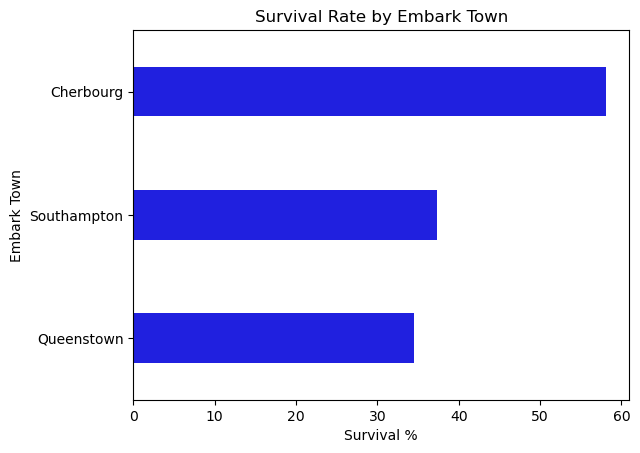

In [392]:
# هون بدي قارن نسب النجاة بين عدة موانئ بهالحالة Barplot هي الانسب  انا عملتها horizontal bar plot
fig_3 = sns.barplot(survival_port,y="embark_town",x="Survival_Percentage",color="blue",width=0.4)
fig_3.set_title("Survival Rate by Embark Town")
fig_3.set_xlabel("Survival %")
fig_3.set_ylabel("Embark Town")

cherbourg ميناء الصعود 

 فيه نسب نجاة اعلى من باقي الموانئ و ذلك من الممكن ان يكون مرتبط بفئة التذكرة و الجنس بحيث انه عندما قمنا بالتحليل بناءا  على الجنس و فئة التذكرة كان واضحا ان الاناث هم الاعلى نسبة بالنجاة و كذلك اصحاب الدرجة الاولى 


Question # 4
هل وجود عائلة على متن السفينة (sibsp + parch > 0) أثّر على احتمال النجاة؟ (بدك تحسب عمود جديد أول).

In [393]:
messy_titanic["family_size"]=messy_titanic["sibsp"] + messy_titanic["parch"]
messy_titanic["family_status"] = (messy_titanic["family_size"] > 0).map({True:"With Family",False:"Alone"})
family_survival = messy_titanic.groupby("family_status")["survived"].mean().reset_index(name="survival_percentage").sort_values(by="survival_percentage",ascending=False)
family_survival["survival_percentage"]=family_survival["survival_percentage"]*100

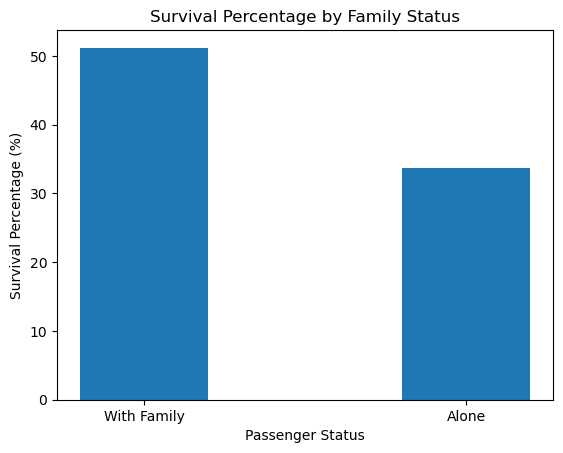

In [394]:
plt.bar(family_survival["family_status"],family_survival["survival_percentage"],width=0.4)
plt.title("Survival Percentage by Family Status")
plt.xlabel("Passenger Status")
plt.ylabel("Survival Percentage (%)")
plt.show()


تظهر الرسمة ان نسبة نجاة الركاب الذي سافروا بمفردهم كانت اقل بشكل واضح مقارنة بنسبة نجاة الركاب الذين صعدوا للرحلة مع عائلاتهم مما يشير الى ان فرص النجاة مرتبطة بالسفر مع العائلة لكن دون ان يثبت ان وجود العائلة هو السبب المباشر او الرئيس

Question #5
شو متوسط العمر لكل فئة، ولكل حالة نجاة (ناجي/غير ناجي) مع بعض؟

In [395]:
average_age = messy_titanic.groupby(["survived","pclass"])["age"].mean().reset_index(name = 'Age Average').sort_values(by = "Age Average",ascending=False)
average_age["survived"] = average_age["survived"].map({0:"Not Survived",1:"Survived"})

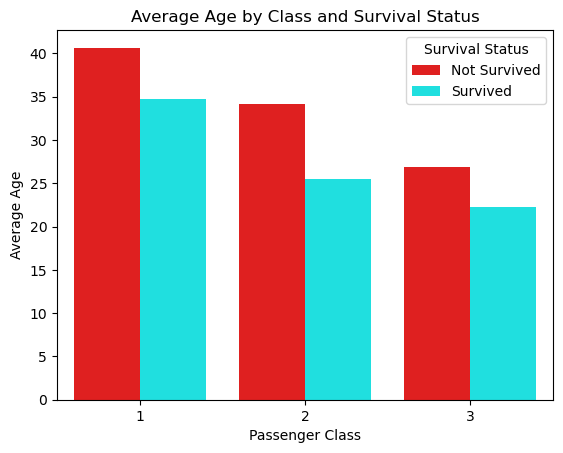

In [396]:
sns.barplot(data=average_age,x="pclass",y="Age Average",hue="survived",palette={"Not Survived":"red","Survived":"cyan"})

plt.title("Average Age by Class and Survival Status")
plt.xlabel("Passenger Class")
plt.ylabel("Average Age")
plt.legend(title="Survival Status")
plt.show()

يوضح الرسم أن متوسط عمر الركاب غير الناجين كان أعلى من متوسط عمر الناجين ضمن جميع فئات الركاب. قد يشير ذلك إلى وجود ارتباط بين العمر واحتمالية النجاة، مع اهمية اخد عوامل الجنس و الفئة بعين الاعتبار

Question #6
هل تختلف فرص النجاة بين الذكور و الاناث , وهل يختلف حسب الفئة ؟

In [397]:
Gender_Survival_Percentage = messy_titanic.groupby(["pclass","sex"])["survived"].mean().reset_index(name="Survival Percentage").sort_values(by="Survival Percentage",ascending=False)
Gender_Survival_Percentage["Survival Percentage"] = Gender_Survival_Percentage["Survival Percentage"]*100
Gender_Survival_Percentage

,pclass,sex,Survival Percentage
0,1,female,96.774194
2,2,female,91.666667
4,3,female,47.244094
1,1,male,37.815126
3,2,male,18.478261
5,3,male,15.884477


In [398]:
fig_6= px.bar(Gender_Survival_Percentage,y="Survival Percentage",x="pclass",color="sex",barmode="group",
    title="Survival Percentage by Gender and Passenger Class",
    labels={"pclass": "Passenger Class","survival_percentage": "Survival Percentage (%)","sex": "Gender"},
    color_discrete_map={"female":"pink","male":"cyan"})
fig_6.show()
fig_6.write_html("Survival Percentage by Gender and Passenger Class.html")

يظهر الرسم ارتفاع نسبة نجاة الإناث مقارنة بالذكور في جميع الفئات. كما سجلت الفئة الأولى أعلى نسبة نجاة، تليها الفئة الثانية ثم الثالثة، مما يعكس اختلاف فرص النجاة باختلاف كل من الجنس والفئة الاجتماعية للراكب

<div dir="rtl" align="right">
# قرارت تنظيف البيانات 

#بداية الداتا كانت تتكون من 906 صفوف و 15 عمود 

#نسب الداتا المفقوده بكل عمود كانت كالتالي 
- deck       :    77%
- age        :    19.86%
- embarked   :    0.22%
- embark_town:    0.22%

1- deck : نسبة الداتا المفقوده فيه كبيرة جدا بالتالي الاستبدال بداتا غير دقيقه ممكن يؤثر على نتيجة التحليل فيما بعد لذلك ارتأيت حذف العمود

2- age : نسبة الداتا المفقودة متوسطه نوعا ما , بالبداية فحصت العمود اذا فيه قيم شاذه و توزيع الاعمار فيه و وجدت انه هناك قيم متطرفة و كانت قيمتها كبيرة لذلك ارتايت التعويض بالوسيط بدل المتوسط لانه لا يتأثر بالقيم بالمتطرفة 

3- embarked , embark_town : عدد القيم المفقودة 2 ,قيم بسيطة جدا لذلك استبدلتها بالقيم الاكثر تكرار

#بالنسبة لمشاكل ادخال النصوص في ال embarked_town تم توحيد تنسيق النصوص بحيث تبدا جميعا بحرف كبير و الباقي صغير

#عدد التسجيلات المكررة كان 120 صف و تم حذفها و بالتالي البيانات اصبحت 786 صف

#عملية حذف العمود deck ادت الى تواجد 6 تسجيلات متكررة بحيث تبين ان تلك الصفوف كانت تختلف بالداتا الموجوده بهذا العمود

تم حذف ال 6 تسجيلات ,بحيث اصبحت الداتا 
780 صف , 14 عمود

<div>


<div dir="rtl" align="right">

العوامل التي ارتبطت بفرص نجاة الركاب خلال الرحلة

أظهرت النتائج أن فئة التذكرة ارتبطت بشكل واضح بمعدلات النجاة، حيث حقق ركاب الفئة الأولى أعلى معدلات نجاة مقارنة بالفئتين الثانية والثالثة، مما يعكس الإختلاف في فرص الوصول إلى وسائل الإنقاذ بين الفئات المختلفة. كما تبين أن الركاب الذين كانوا برفقة أفراد من عائلاتهم حققوا معدلات نجاة أعلى مقارنةً بالمسافرين بمفردهم، مما يشير إلى ارتباط وجود أفراد من العائلة بارتفاع فرص النجاة.

كما أظهرت النتائج وجود اختلاف كبير في معدلات النجاة بين الذكور والإناث، حيث كانت فرص نجاة النساء أعلى بشكل واضح ضمن جميع الفئات. بالإضافة إلى ذلك، لوحظ أن متوسط أعمار الركاب الذين لم ينجوا كان أعلى من متوسط أعمار الناجين، مما يشير إلى وجود اختلافات واضحة في معدلات النجاة تبعا لعمر الركاب وجنسهم وفئة التذكرة ووجود أفراد من العائلة.
<div>